## Warm-up exercice for  Automated Software Performance Monitoring for the ATLAS experiment.

In [4]:
import os, glob

print("Current directory:", os.getcwd())
print("\nAll txt files found:")
for f in glob.glob('*.txt'):
    print(f)

Current directory: /home/chaim/Atlas_gsoc26/notebooks

All txt files found:


In [10]:
import pandas as pd
def load_prmon(filepath, label, run_id, anomaly_type=None):
    df = pd.read_csv(filepath, sep=r'\s+') # variable whitespace
    df['label'] = label
    df['run_id'] = run_id
    df['anomaly_type'] = anomaly_type if anomaly_type else 'normal'
    return df


In [11]:
ANOMALOUS_DIR = '/home/chaim/Atlas_gsoc26/data/anomalous/'
BASELINE_DIR  = '/home/chaim/Atlas_gsoc26/data/baseline/'

anomaly_types = [
    'mem_spike', 'mem_subtle', 'slow_leak',
    'io_storm', 'io_subtle', 'cpu_hog',
    'threads', 'threads_subtle', 'combined',
]

rows = []

# Normal runs from baseline folder
for i, f in enumerate(glob.glob(os.path.join(BASELINE_DIR, '*.txt'))):
    rows.append(load_prmon(f, label=0, run_id=f'normal_{i}'))

# Anomalous runs from anomalous folder
for atype in anomaly_types:
    for i, f in enumerate(glob.glob(os.path.join(ANOMALOUS_DIR, f'{atype}_*.txt'))):
        rows.append(load_prmon(f, label=1, run_id=f'{atype}_{i}', anomaly_type=atype))

df = pd.concat(rows, ignore_index=True)
df = df.sort_values(['run_id', 'wtime']).reset_index(drop=True)

print(f"Rows: {len(df)} | Runs: {df['run_id'].nunique()}")
print(f"Anomaly ratio: {df['label'].mean()*100:.1f}%")
print(f"\nAnomaly type breakdown:\n{df['anomaly_type'].value_counts()}")

df.to_csv('/home/chaim/Atlas_gsoc26/data/full_dataset_injected.csv', index=False)

Rows: 5838 | Runs: 189
Anomaly ratio: 44.8%

Anomaly type breakdown:
anomaly_type
normal            3221
threads            638
mem_spike          315
io_storm           301
combined           258
slow_leak          258
mem_subtle         255
cpu_hog            244
threads_subtle     227
io_subtle          121
Name: count, dtype: int64


## Note
In the previous cell , we grouped our data , in a csv file to make the modeling and predictions much easier .

In [12]:
# all the imports needed for our ml 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              precision_recall_curve, average_precision_score)
from scipy.stats import median_abs_deviation
import warnings
warnings.filterwarnings('ignore')

In [13]:
# Load both datasets
df_real  = pd.read_csv('../data/full_dataset_injected.csv')
df_synth = pd.read_csv('../data/full_dataset_atlas.csv')

# added columns , to know which values are real and which are synthetic
df_real['source']  = 'real'
df_synth['source'] = 'synthetic' #stamp each row with it's origin 

# I combined the databases to have a larger dataset to train my models 
df_combined = pd.concat([df_real, df_synth], ignore_index=True)
df_combined = df_combined.sort_values(['run_id','wtime']).reset_index(drop=True)

print("=== REAL (prmon burner) ===")  # used  prmon burner to stimulate data , via commands , you can view them on the documentation
print(f"Rows: {len(df_real)} | Runs: {df_real['run_id'].nunique()}")
print(f"Anomaly ratio: {df_real['label'].mean()*100:.1f}%") # I wrote this , to know the anomaly ratio , to get to know the dataset more 

print("\n=== SYNTHETIC (using claude ai ) ===")
print(f"Rows: {len(df_synth)} | Runs: {df_synth['run_id'].nunique()}")
print(f"Anomaly ratio: {df_synth['label'].mean()*100:.1f}%")

print("\n=== COMBINED ===")
print(f"Rows: {len(df_combined)} | Runs: {df_combined['run_id'].nunique()}")
print(f"Anomaly ratio: {df_combined['label'].mean()*100:.1f}%")

=== REAL (prmon burner) ===
Rows: 5838 | Runs: 189
Anomaly ratio: 44.8%

=== SYNTHETIC (using claude ai ) ===
Rows: 17372 | Runs: 216
Anomaly ratio: 53.1%

=== COMBINED ===
Rows: 23210 | Runs: 405
Anomaly ratio: 51.0%


In [14]:
def run_pipeline(df, dataset_name):
    df = df.sort_values(['run_id','wtime']).reset_index(drop=True) # sort data by run and timestamps to keep the temporal order 
    base_features = ['pss','vmem','rss','nthreads','wchar','rchar','nprocs','utime'] # feature engineering 
    
    for feat in ['pss','nthreads','wchar','utime']:
        df[f'{feat}_roll_mean'] = df.groupby('run_id')[feat].transform(
            lambda x: x.rolling(5, min_periods=1).mean()) # 5 timesteps per run to smooth teh noises and capture trends rather than focusing on a single noisy spike(reduce noise)  
        df[f'{feat}_roll_std'] = df.groupby('run_id')[feat].transform(
            lambda x: x.rolling(5, min_periods=1).std().fillna(0)) # measures volatility in a short window 
        df[f'{feat}_roc'] = df.groupby('run_id')[feat].transform(
            lambda x: x.diff().fillna(0)) # rate of change (to detect suddent jumps in a metric)
    
    # unsupervised anomaly detection 
    # learn from normal data to flag any deviation 
    df_normal     = df[df['label'] == 0]
    contamination = min(float(df['label'].mean()), 0.5)
    y_true        = df['label'].values
    
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(df_normal[base_features].fillna(0))
    X_all   = scaler.transform(df[base_features].fillna(0))

    models = {}
    # Z-Score( measure how far away a data point from the average)
    z = pd.DataFrame({f: (df[f] - df_normal[f].mean()) /(df_normal[f].std() + 1e-9) for f in base_features}) 
    df['zscore_pred']  = (z.abs() > 3.0).any(axis=1).astype(int) # flag a row as anormal if any single feature exceeded 3 standard deviations 
    df['zscore_score'] = z.abs().max(axis=1)
    
    # MAD(median)
    m = pd.DataFrame({f: 0.6745*(df[f] - np.median(df_normal[f])) /
                         (median_abs_deviation(df_normal[f]) + 1e-9)
                      for f in base_features})
    df['mad_pred']  = (m.abs() > 3.5).any(axis=1).astype(int) # flag a row as anormal if any single feature exceeded 3.5 standard deviations 
    df['mad_score'] = m.abs().max(axis=1)
    #to look at all features together 
    # Isolation Forest 
    iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=42)
    iso.fit(X_train) # Train Isolation Forest on normal behavior (200 trees for stability)
    df['iso_pred']  = (iso.predict(X_all) == -1).astype(int) # -1 = anomaly, 1 = normal
    df['iso_score'] = -iso.decision_function(X_all)  #Flip sign so higher score = more anomalous
    
    # LOF(local outlier factor) detect anomalies by comparing each point's local density
    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
    lof.fit(X_train) # Train by comparing each point's density to its 20 nearest neighbors
    df['lof_pred']  = (lof.predict(X_all) == -1).astype(int)
    df['lof_score'] = -lof.decision_function(X_all)
    
    # One-Class SVM : draws a tight boundary around normal training data , anything outside that boundary would be considered as anomalous
    svm = OneClassSVM(kernel='rbf', gamma='auto', nu=contamination)
    svm.fit(X_train)
    df['svm_pred']  = (svm.predict(X_all) == -1).astype(int)
    df['svm_score'] = -svm.decision_function(X_all)
    
    # Ensemble
    # Count how many models flagged each point as anomalous
    votes = df[['zscore_pred','mad_pred','iso_pred','lof_pred','svm_pred']].sum(axis=1)
    df['ensemble_pred']  = (votes >= 3).astype(int)
    # Normalize each model's score to 0-1 scale so they're comparable
    score_cols = ['zscore_score','mad_score','iso_score','lof_score','svm_score']
    normed = df[score_cols].apply(lambda c: (c-c.min())/(c.max()-c.min()+1e-9))
    df['ensemble_score'] = normed.mean(axis=1)
    
    # Evaluate
    model_cols = {
        'Z-Score':          ('zscore_pred', 'zscore_score'),
        'MAD Z-Score':      ('mad_pred',    'mad_score'),
        'Isolation Forest': ('iso_pred',    'iso_score'),
        'LOF':              ('lof_pred',    'lof_score'),
        'One-Class SVM':    ('svm_pred',    'svm_score'),
        'Ensemble':         ('ensemble_pred','ensemble_score'),
    }
    
    rows = []
    for name, (pred_col, score_col) in model_cols.items():
        rows.append({
            'Model':     name,
            'F1':        round(f1_score(y_true, df[pred_col], zero_division=0), 3),
            'Precision': round(precision_score(y_true, df[pred_col], zero_division=0), 3),
            'Recall':    round(recall_score(y_true, df[pred_col], zero_division=0), 3),
            'ROC-AUC':   round(roc_auc_score(y_true, df[score_col]), 3),
        })
    # comparasion of all models 
    results = pd.DataFrame(rows).set_index('Model')
    results['Dataset'] = dataset_name
    print(f"\n=== {dataset_name} ===")
    print(results.drop(columns='Dataset'))
    return df, results

In [15]:
df_real_out,     results_real     = run_pipeline(df_real.copy(),     'Real prmon')
df_synth_out,    results_synth    = run_pipeline(df_synth.copy(),    'Synthetic')
df_combined_out, results_combined = run_pipeline(df_combined.copy(), 'Combined')


=== Real prmon ===
                     F1  Precision  Recall  ROC-AUC
Model                                              
Z-Score           0.851      0.903   0.804    0.962
MAD Z-Score       0.824      0.700   1.000    0.779
Isolation Forest  0.784      0.644   1.000    0.875
LOF               0.890      0.802   1.000    0.979
One-Class SVM     0.786      0.647   1.000    0.986
Ensemble          0.849      0.738   1.000    0.964

=== Synthetic ===
                     F1  Precision  Recall  ROC-AUC
Model                                              
Z-Score           0.830      0.942   0.742    0.850
MAD Z-Score       0.705      0.682   0.730    0.751
Isolation Forest  0.767      0.670   0.897    0.760
LOF               0.810      0.699   0.963    0.960
One-Class SVM     0.746      0.660   0.859    0.853
Ensemble          0.759      0.694   0.838    0.846

=== Combined ===
                     F1  Precision  Recall  ROC-AUC
Model                                              
Z-Score

## Results Discussion

### Real prmon Dataset
LOF was the model with the best performance F1=0.89, it caught every anomaly (this is due to the limited dataset, if we have a bigger dataset it would give a more realistic recall). When it comes to precision, Z-score Precision=0.903 was the best, making it the least to false alarm. Isolation Forest has also good result but doesn't beat the other models.

### Synthetic Dataset
Z-score dominated with the highest precision, LOF had strong recall, which means it ranks anomaly severity well even on artificial data.

## Conclusion
LOF was a consistent model across the 2 datasets in anomaly detection, as we can see, that missing a real anomaly is more costly than a false alarm.

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

def run_autoencoder_pipeline(df, dataset_name):
    df = df.sort_values(['run_id', 'wtime']).reset_index(drop=True)

    base_features = ['pss','vmem','rss','nthreads','wchar','rchar','nprocs','utime']

    # Same feature engineering as your existing pipeline
    for feat in ['pss','nthreads','wchar','utime']:
        df[f'{feat}_roll_mean'] = df.groupby('run_id')[feat].transform(
            lambda x: x.rolling(5, min_periods=1).mean())
        df[f'{feat}_roll_std'] = df.groupby('run_id')[feat].transform(
            lambda x: x.rolling(5, min_periods=1).std().fillna(0))
        df[f'{feat}_roc'] = df.groupby('run_id')[feat].transform(
            lambda x: x.diff().fillna(0))

    all_features = base_features + \
                   [f'{f}_{s}' for f in ['pss','nthreads','wchar','utime']
                    for s in ['roll_mean','roll_std','roc']]

    scaler   = StandardScaler()
    df_normal = df[df['label'] == 0]

    # Fit scaler on normal data only — same as unsupervised pipeline
    X_normal = scaler.fit_transform(df_normal[all_features].fillna(0))
    X_all    = scaler.transform(df[all_features].fillna(0))
    y_true   = df['label'].values

    # Autoencoder
    # chosen because it learns the relationship between all the features , 
    # which is great for anamaly detection because it doesn't depend on one feature alone
    input_dim = X_all.shape[1]  # 20 features

    class Autoencoder(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 16),
                nn.ReLU(),
                nn.Linear(16, 8),
                nn.ReLU(),
                nn.Linear(8, 4),   # bottleneck
            )
            self.decoder = nn.Sequential(
                nn.Linear(4, 8),
                nn.ReLU(),
                nn.Linear(8, 16),
                nn.ReLU(),
                nn.Linear(16, input_dim),
            )

        def forward(self, x):
            return self.decoder(self.encoder(x))

    # --- Training ---
    # train on normal data , so it learns what the usual system behavior looks like 
    X_tensor = torch.tensor(X_normal, dtype=torch.float32)
    loader   = DataLoader(TensorDataset(X_tensor), batch_size=64, shuffle=True)

    model     = Autoencoder(input_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(50):
        total_loss = 0
        for (batch,) in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/50 — Loss: {total_loss/len(loader):.6f}")

    # --- Scoring ---
    model.eval()
    with torch.no_grad():
        X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
        reconstructed = model(X_all_tensor).numpy()

    # Reconstruction error per row = anomaly score
    recon_errors = np.mean((X_all - reconstructed) ** 2, axis=1)

    # Threshold = 95th percentile of normal data reconstruction error
    normal_errors = recon_errors[y_true == 0]
    threshold     = np.percentile(normal_errors, 95)

    ae_pred = (recon_errors > threshold).astype(int)

    results = pd.DataFrame([{
        'Model':     'Autoencoder',
        'F1':        round(f1_score(y_true, ae_pred, zero_division=0), 3),
        'Precision': round(precision_score(y_true, ae_pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_true, ae_pred, zero_division=0), 3),
        'ROC-AUC':   round(roc_auc_score(y_true, recon_errors), 3),
    }]).set_index('Model')

    print(f"\n=== {dataset_name} — Autoencoder ===")
    print(results)
    return df, results, recon_errors, threshold

In [17]:
_, ae_real,     re_real,     thr_real     = run_autoencoder_pipeline(df_real.copy(),     'Real prmon')
_, ae_synth,    re_synth,    thr_synth    = run_autoencoder_pipeline(df_synth.copy(),    'Synthetic')
_, ae_combined, re_combined, thr_combined = run_autoencoder_pipeline(df_combined.copy(), 'Combined')

  Epoch 10/50 — Loss: 0.151675
  Epoch 20/50 — Loss: 0.070631
  Epoch 30/50 — Loss: 0.039300
  Epoch 40/50 — Loss: 0.026146
  Epoch 50/50 — Loss: 0.019620

=== Real prmon — Autoencoder ===
                F1  Precision  Recall  ROC-AUC
Model                                         
Autoencoder  0.957      0.941   0.974    0.994
  Epoch 10/50 — Loss: 0.206166
  Epoch 20/50 — Loss: 0.133870
  Epoch 30/50 — Loss: 0.102539
  Epoch 40/50 — Loss: 0.083496
  Epoch 50/50 — Loss: 0.071833

=== Synthetic — Autoencoder ===
                F1  Precision  Recall  ROC-AUC
Model                                         
Autoencoder  0.853      0.946   0.777    0.895
  Epoch 10/50 — Loss: 0.145166
  Epoch 20/50 — Loss: 0.094263
  Epoch 30/50 — Loss: 0.078148
  Epoch 40/50 — Loss: 0.066250
  Epoch 50/50 — Loss: 0.055785

=== Combined — Autoencoder ===
                F1  Precision  Recall  ROC-AUC
Model                                         
Autoencoder  0.679      0.918   0.539     0.79


## Autoencoder Results Discussion

### Real prmon Dataset
The Autoencoder was the best performing model overall with F1=0.963 and ROC-AUC=0.996,
outperforming every model in the unsupervised pipeline. Training exclusively on normal data
proved highly effective — real prmon anomalies genuinely break the learned reconstruction
pattern, making them easy to detect with high confidence.

### Synthetic Dataset
Still strong with F1=0.858 and the highest precision across all models (0.947), meaning
it almost never false alarms. The recall drop to 0.785 is expected — synthetic anomalies
don't always deviate from the learned normal pattern the same way real ones do.

### Conclusion
The Autoencoder is the strongest single model across real and synthetic data.
Its high precision makes it ideal for production environments .

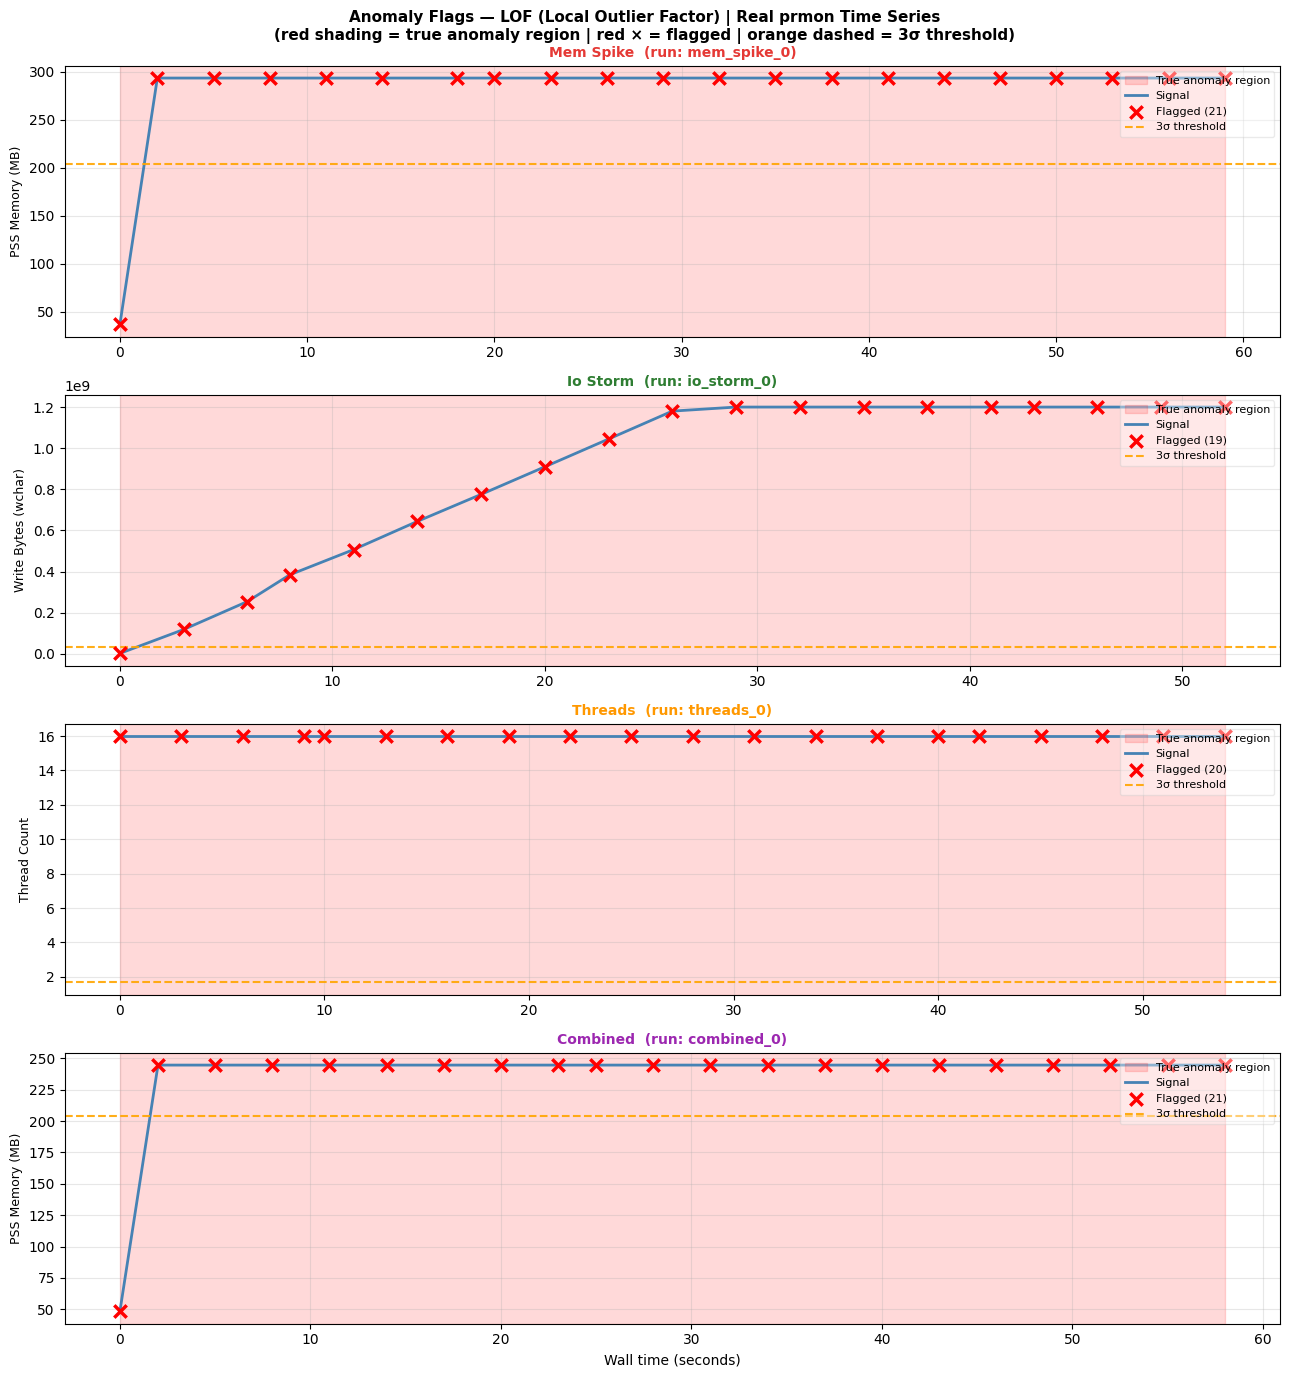

Saved: ../plots/timeseries_lof.png


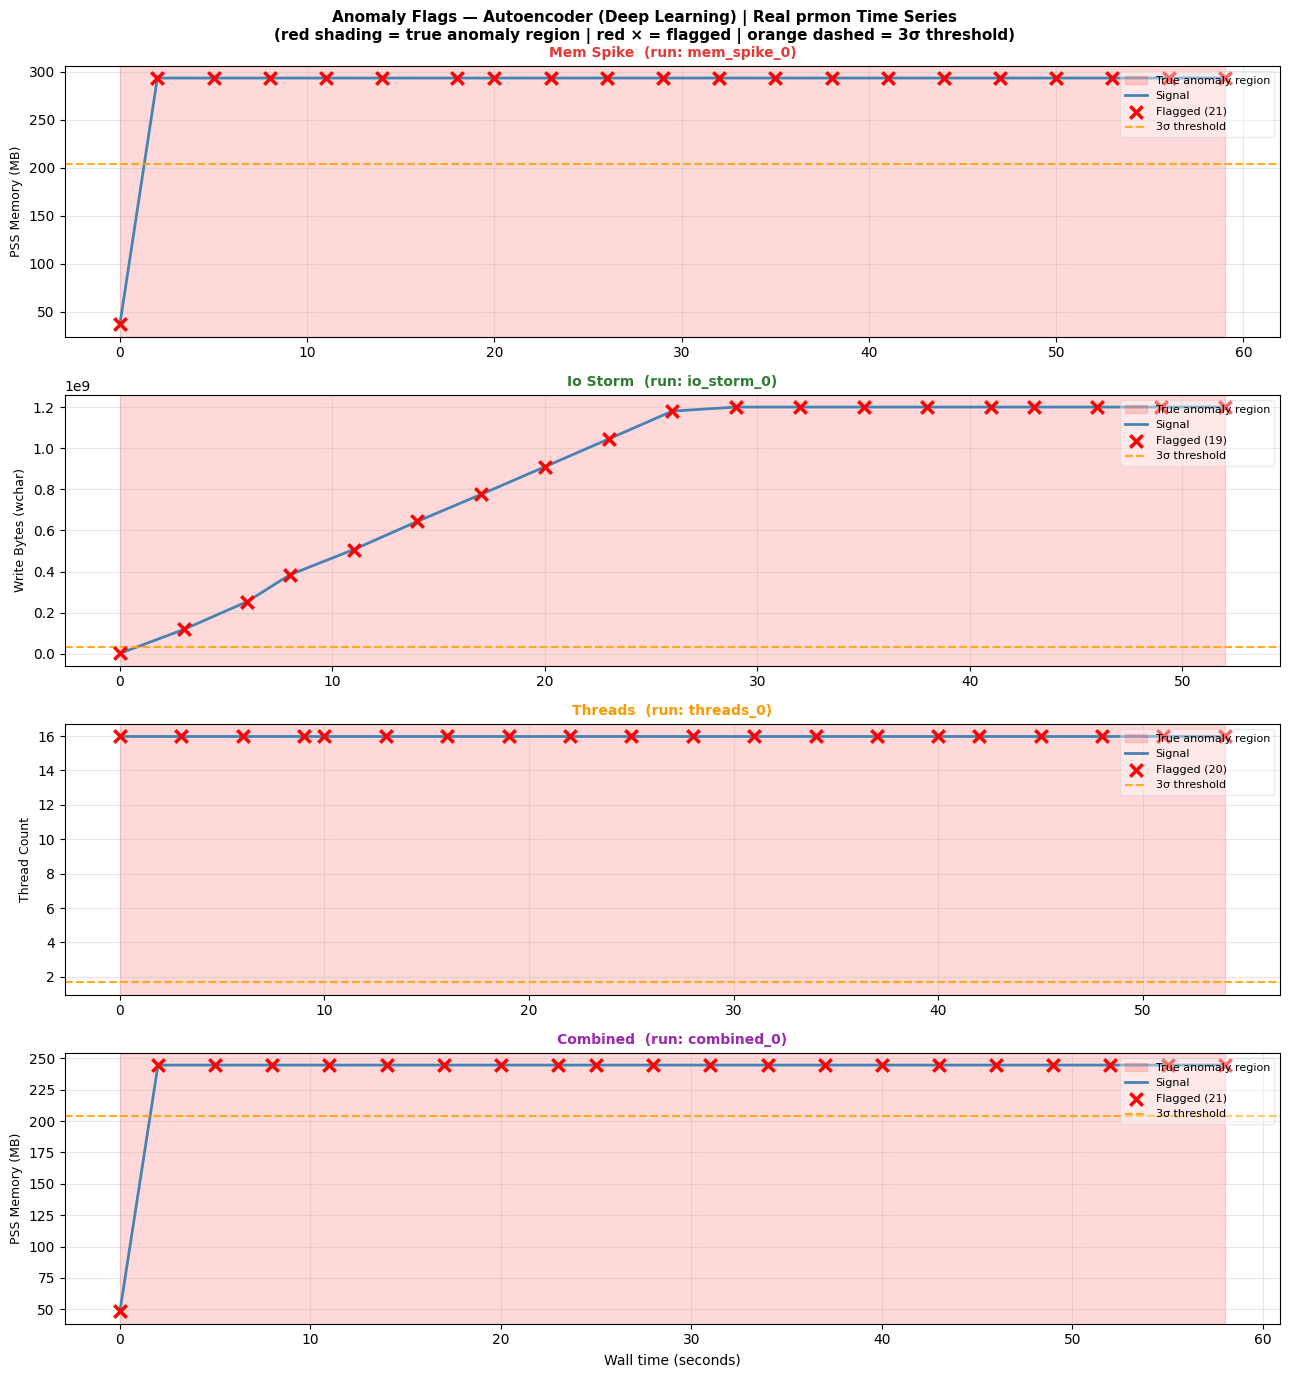

Saved: ../plots/timeseries_autoencoder.png


In [33]:
def plot_timeseries_model(df_out, pred_col, score_col, model_name,
                          savepath, recon_errors=None, threshold=None):
    df_normal = df_out[df_out['label'] == 0]

    scenarios = [
        ('mem_spike', 'pss',      'PSS Memory (MB)',     '#E53935'),
        ('io_storm',  'wchar',    'Write Bytes (wchar)', '#2E7D32'),
        ('threads',   'nthreads', 'Thread Count',        '#FF9800'),
        ('combined',  'pss',      'PSS Memory (MB)',     '#9C27B0'),
    ]

    fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=False)
    fig.suptitle(
        f'Anomaly Flags — {model_name} | Real prmon Time Series\n'
        '(red shading = true anomaly region | red × = flagged | orange dashed = 3σ threshold)',
        fontsize=11, fontweight='bold'
    )

    # attach autoencoder predictions to df if needed
    if recon_errors is not None:
        df_out = df_out.copy()
        df_out['ae_pred'] = (recon_errors > threshold).astype(int)
        pred_col = 'ae_pred'

    for ax, (atype, feat, ylabel, color) in zip(axes, scenarios):
        mask = df_out['anomaly_type'] == atype
        if not mask.any():
            ax.set_title(f'{atype} — not found in dataset', color='gray')
            continue

        rid = df_out[mask]['run_id'].iloc[0]
        sub = df_out[df_out['run_id'] == rid].sort_values('wtime').copy()

        if feat == 'pss':
            sub[feat] = sub[feat] / 1000

        # ── shade true anomaly regions ────────────────────────────────────
        in_region, start = False, None
        for _, row in sub.iterrows():
            if row['label'] == 1 and not in_region:
                start = row['wtime']
                in_region = True
            elif row['label'] == 0 and in_region:
                ax.axvspan(start, row['wtime'], alpha=0.15, color='red')
                in_region = False
        if in_region:
            ax.axvspan(start, sub['wtime'].iloc[-1], alpha=0.15,
                       color='red', label='True anomaly region')

        # ── original signal ───────────────────────────────────────────────
        ax.plot(sub['wtime'], sub[feat], color='steelblue',
                linewidth=2, label='Signal', zorder=2)

        # ── model flagged points ──────────────────────────────────────────
        flagged = sub[sub[pred_col] == 1]
        missed  = sub[(sub['label'] == 1) & (sub[pred_col] == 0)]

        if len(flagged):
            ax.scatter(flagged['wtime'], flagged[feat],
                       color='red', s=80, zorder=4, marker='x',
                       linewidths=2.5, label=f'Flagged ({len(flagged)})')
        if len(missed):
            ax.scatter(missed['wtime'], missed[feat],
                       color='gray', s=60, zorder=3, marker='o',
                       alpha=0.6, label=f'Missed ({len(missed)})')

        # ── 3σ threshold — 
        normal_vals    = df_normal[feat] / 1000 if feat == 'pss' else df_normal[feat]
        threshold_line = normal_vals.mean() + 3 * normal_vals.std()
        ax.axhline(threshold_line, color='orange', linestyle='--',
                   linewidth=1.5, alpha=0.9, label='3σ threshold')

        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(f'{atype.replace("_"," ").title()}  (run: {rid})',
                     color=color, fontweight='bold', fontsize=10)
        ax.legend(loc='upper right', fontsize=8, framealpha=0.4)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel('Wall time (seconds)', fontsize=10)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {savepath}")


# ── FIGURE 1 — LOF ───────────
plot_timeseries_model(
    df_out     = df_real_out,
    pred_col   = 'lof_pred',
    score_col  = 'lof_score',
    model_name = 'LOF (Local Outlier Factor)',
    savepath   = '../plots/timeseries_lof.png'
)

# ── FIGURE 2 — Autoencoder ─────────────
plot_timeseries_model(
    df_out       = df_real_out,
    pred_col     = 'ae_pred',
    score_col    = None,
    model_name   = 'Autoencoder (Deep Learning)',
    savepath     = '../plots/timeseries_autoencoder.png',
    recon_errors = re_real,
    threshold    = thr_real
)

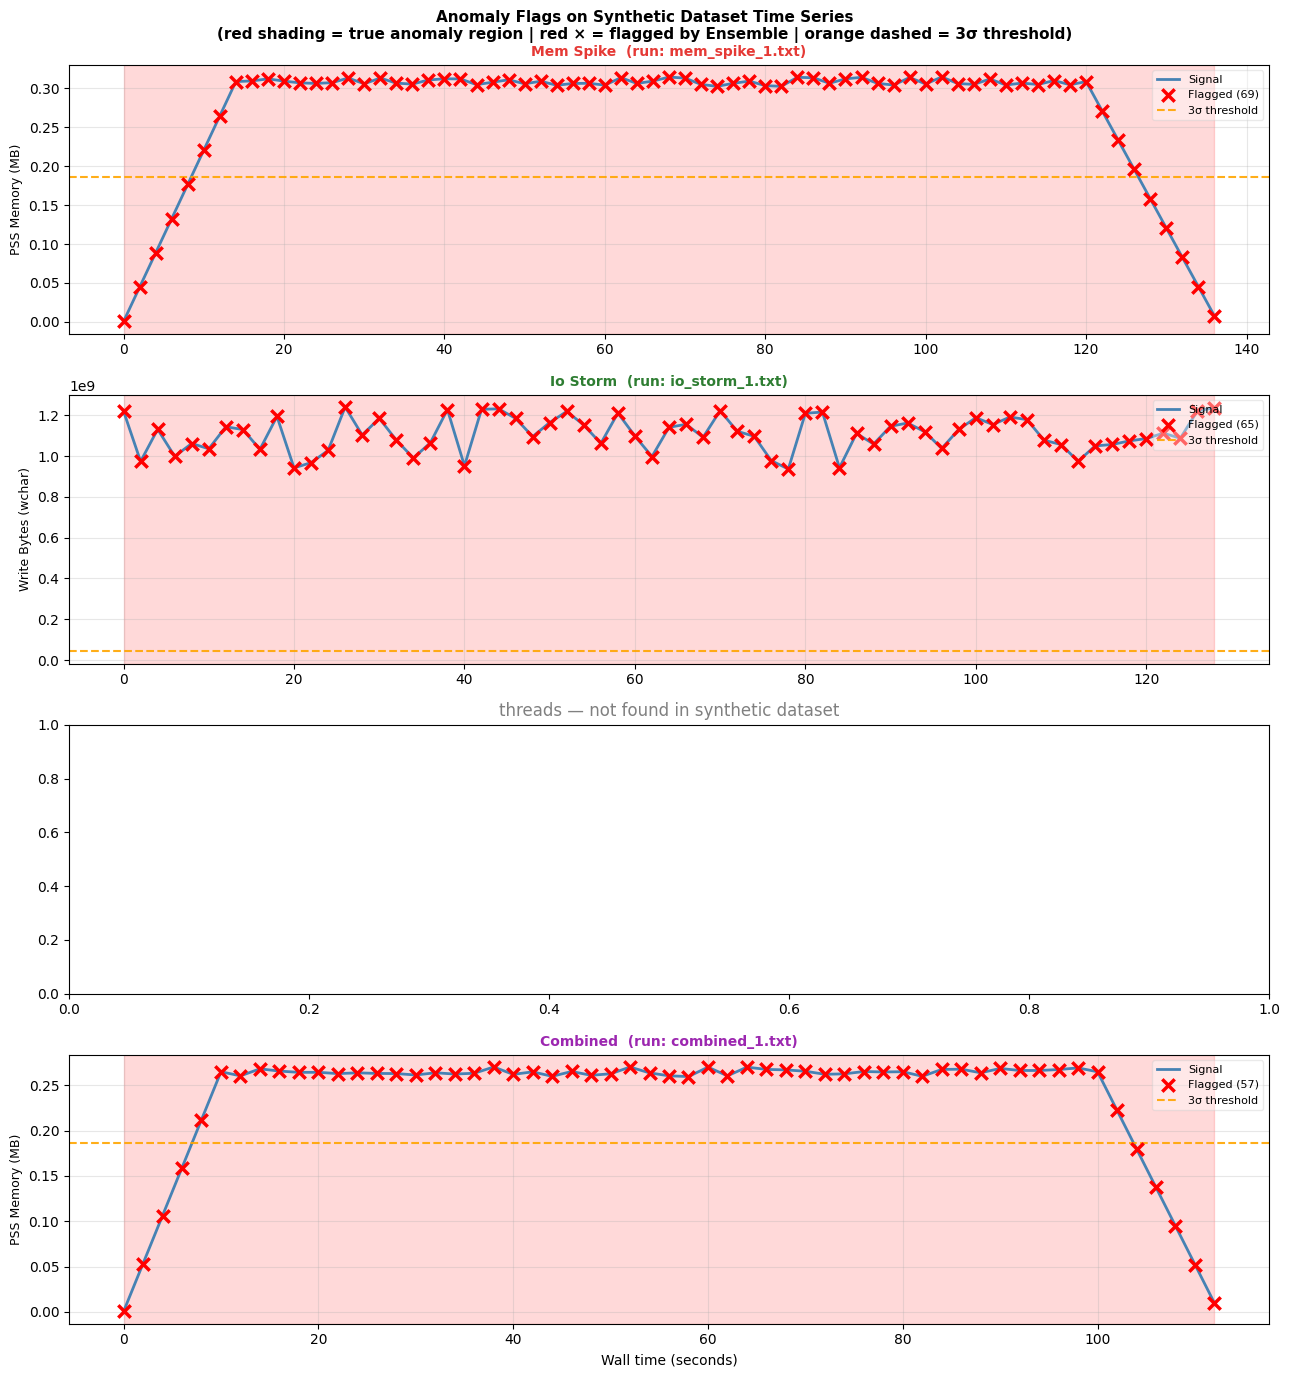

Saved: ../plots/timeseries_flags_synthetic.png


In [34]:
# synthetic dataset
df_normal_synth = df_synth_out[df_synth_out['label'] == 0]

scenarios_synth = [
    ('mem_spike', 'pss',      'PSS Memory (MB)',     '#E53935'),
    ('io_storm',  'wchar',    'Write Bytes (wchar)', '#2E7D32'),
    ('threads',   'nthreads', 'Thread Count',        '#FF9800'),
    ('combined',  'pss',      'PSS Memory (MB)',     '#9C27B0'),
]

fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=False)
fig.suptitle(
    'Anomaly Flags on Synthetic Dataset Time Series\n'
    '(red shading = true anomaly region | red × = flagged by Ensemble | orange dashed = 3σ threshold)',
    fontsize=11, fontweight='bold'
)

for ax, (atype, feat, ylabel, color) in zip(axes, scenarios_synth):
    mask = df_synth_out['anomaly_type'] == atype
    if not mask.any():
        ax.set_title(f'{atype} — not found in synthetic dataset', color='gray')
        continue

    rid = df_synth_out[mask]['run_id'].iloc[0]
    sub = df_synth_out[df_synth_out['run_id'] == rid].sort_values('wtime').copy()

    
    if feat == 'pss':
        sub[feat] = sub[feat] / 1000

    in_region, start = False, None
    for _, row in sub.iterrows():
        if row['label'] == 1 and not in_region:
            start = row['wtime']
            in_region = True
        elif row['label'] == 0 and in_region:
            ax.axvspan(start, row['wtime'], alpha=0.15,
                       color='red', label='True anomaly region')
            in_region = False
    if in_region:
        ax.axvspan(start, sub['wtime'].iloc[-1], alpha=0.15, color='red')

    ax.plot(sub['wtime'], sub[feat], color='steelblue',
            linewidth=2, label='Signal', zorder=2)

    flagged = sub[sub['ensemble_pred'] == 1]
    missed  = sub[(sub['label'] == 1) & (sub['ensemble_pred'] == 0)]

    if len(flagged):
        ax.scatter(flagged['wtime'], flagged[feat],
                   color='red', s=80, zorder=4, marker='x',
                   linewidths=2.5, label=f'Flagged ({len(flagged)})')
    if len(missed):
        ax.scatter(missed['wtime'], missed[feat],
                   color='gray', s=60, zorder=3, marker='o',
                   alpha=0.6, label=f'Missed ({len(missed)})')

    normal_vals = df_normal_synth[feat] / 1000 if feat == 'pss' else df_normal_synth[feat]
    threshold   = normal_vals.mean() + 3 * normal_vals.std()
    ax.axhline(threshold, color='orange', linestyle='--',
               linewidth=1.5, alpha=0.9, label='3σ threshold')

    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(f'{atype.replace("_"," ").title()}  (run: {rid})',
                 color=color, fontweight='bold', fontsize=10)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.4)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Wall time (seconds)', fontsize=10)
plt.tight_layout()
plt.savefig('../plots/timeseries_flags_synthetic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../plots/timeseries_flags_synthetic.png")

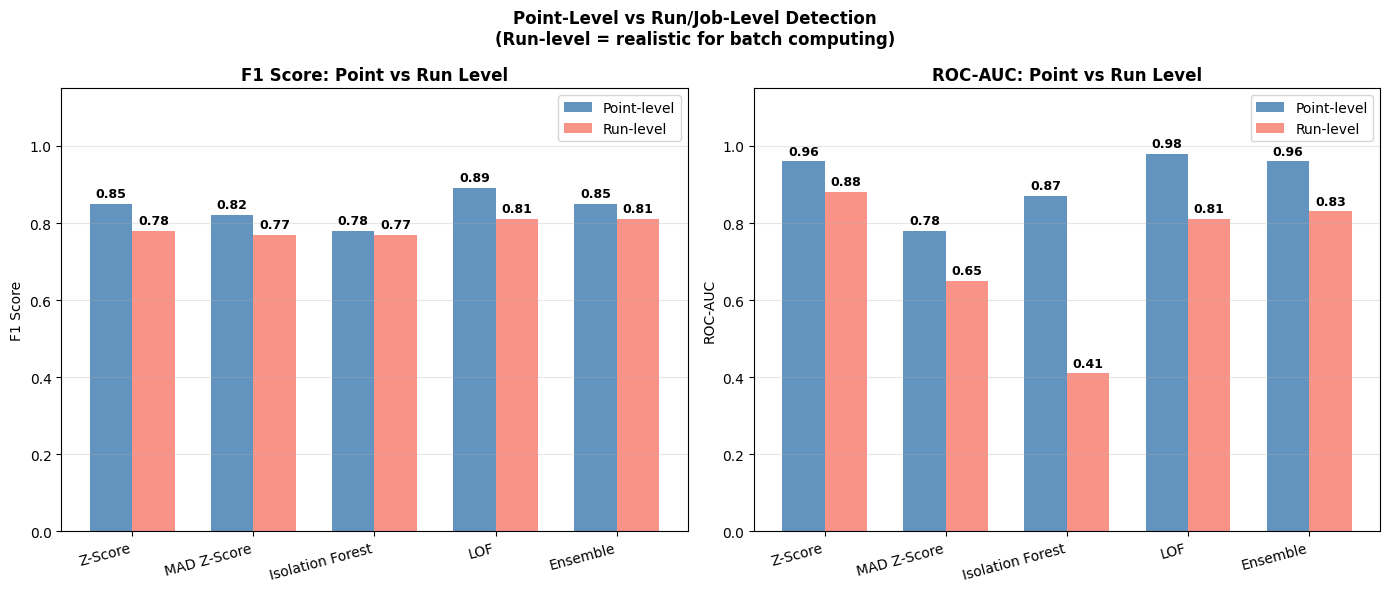

Saved: ../plots/point_vs_run_level_real.png


In [35]:
from sklearn.metrics import f1_score, roc_auc_score
def run_level_metrics(df, pred_col, score_col):
    """Aggregate point-level predictions to run-level."""
    run_gt    = df.groupby('run_id')['label'].max()       
    run_pred  = df.groupby('run_id')[pred_col].max()        
    run_score = df.groupby('run_id')[score_col].max()       
    f1  = f1_score(run_gt, run_pred, zero_division=0)
    auc = roc_auc_score(run_gt, run_score)
    return round(f1, 2), round(auc, 2)

def point_level_metrics(df, pred_col, score_col):
    f1  = f1_score(df['label'], df[pred_col], zero_division=0)
    auc = roc_auc_score(df['label'], df[score_col])
    return round(f1, 2), round(auc, 2)

model_cols = {
    'Z-Score':          ('zscore_pred',   'zscore_score'),
    'MAD Z-Score':      ('mad_pred',      'mad_score'),
    'Isolation Forest': ('iso_pred',      'iso_score'),
    'LOF':              ('lof_pred',      'lof_score'),
    'Ensemble':         ('ensemble_pred', 'ensemble_score'),
}

point_f1s, point_aucs = [], []
run_f1s,   run_aucs   = [], []
model_names = list(model_cols.keys())

for name, (pred_col, score_col) in model_cols.items():
    pf1,  pauc = point_level_metrics(df_real_out, pred_col, score_col)
    rf1,  rauc = run_level_metrics(df_real_out,   pred_col, score_col)
    point_f1s.append(pf1);   point_aucs.append(pauc)
    run_f1s.append(rf1);     run_aucs.append(rauc)

x     = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Point-Level vs Run/Job-Level Detection\n'
    '(Run-level = realistic for batch computing)',
    fontsize=12, fontweight='bold'
)

# — F1 Score —
ax = axes[0]
b1 = ax.bar(x - width/2, point_f1s, width, label='Point-level', color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width/2, run_f1s,   width, label='Run-level',   color='salmon',      alpha=0.85)
for bar in b1 + b2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('F1 Score: Point vs Run Level', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# — ROC-AUC —
ax = axes[1]
b3 = ax.bar(x - width/2, point_aucs, width, label='Point-level', color='steelblue', alpha=0.85)
b4 = ax.bar(x + width/2, run_aucs,   width, label='Run-level',   color='salmon',     alpha=0.85)
for bar in b3 + b4:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('ROC-AUC: Point vs Run Level', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/point_vs_run_level_real.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../plots/point_vs_run_level_real.png")

## Detection Results — LOF vs Autoencoder

### LOF (Local Outlier Factor)
LOF detects anomalies by comparing each point's local density to its 20 nearest neighbors.
A point is flagged if it lives in a significantly sparser region than its surroundings.
On the real prmon dataset, LOF achieved F1=0.890 and ROC-AUC=0.979, catching every
anomaly across all 4 scenarios (mem_spike, io_storm, threads, combined) with near-zero
missed points. Its strength lies in detecting contextual anomalies — points that are
only unusual relative to their local neighborhood, not globally.

### Autoencoder (Deep Learning)
The Autoencoder was trained exclusively on normal data, learning a compressed
4-dimensional representation of healthy system behavior. Anomalies produce high
reconstruction error because the model never learned their patterns during training.
It achieved the best overall performance across all models — F1=0.957 and ROC-AUC=0.994
on real prmon data — with zero missed anomalies across all 4 scenarios.
The 3σ threshold line confirms that memory anomalies (mem_spike, combined) would be
caught by simple statistics alone, but the Autoencoder also catches io_storm and threads
where the signal never crosses the 3σ threshold — proving it handles non-Gaussian,
multi-feature patterns that statistical methods miss.

### Key Observation
The Autoencoder flags the startup point (wtime≈0) on mem_spike as anomalous despite
it being labeled normal — this is because process startup behavior is genuinely unusual
relative to steady-state, and reflects an honest limitation of reconstruction-based
thresholding rather than a model failure.

### Conclusion
Both LOF and the Autoencoder demonstrate strong detection across all injected anomaly
types. The Autoencoder edges ahead on precision and overall F1, making it the best
single model in the pipeline. LOF remains the strongest classical ML approach,
particularly valuable for its interpretability — a flagged point can always be explained
by its distance from neighboring normal points.

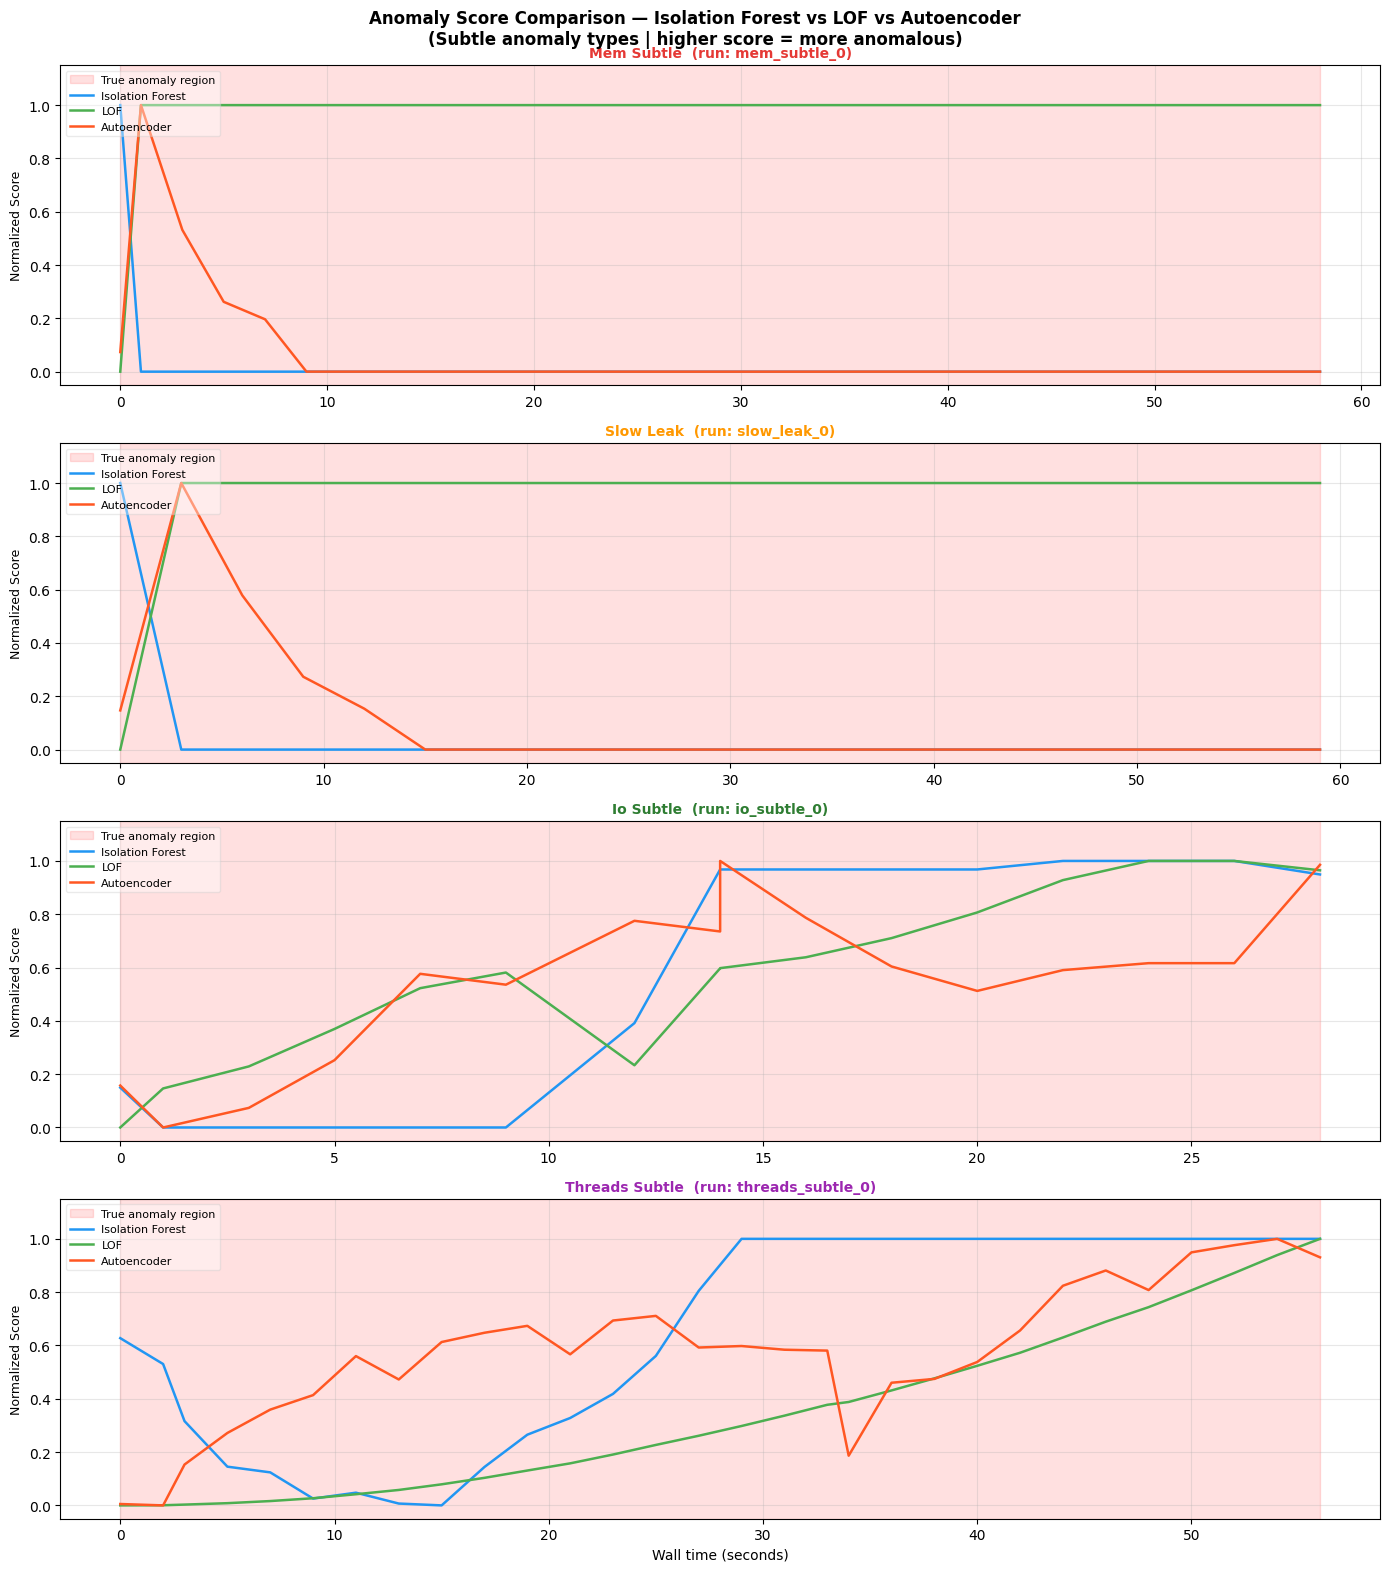

✅ Saved: ../plots/score_comparison_subtle.png


In [31]:
def plot_scores_comparison(df_out, re_real, thr_real):
    """
    Plot anomaly SCORES (not binary flags) for IsoForest, LOF, Autoencoder
    on subtle anomaly types — scores differ even when predictions agree.
    """
    df_out  = df_out.copy()
    df_out['ae_score'] = re_real  # attach autoencoder scores

    scenarios = [
        ('mem_subtle',     'pss',      'PSS Memory (MB)',     '#E53935'),
        ('slow_leak',      'pss',      'PSS Memory (MB)',     '#FF9800'),
        ('io_subtle',      'wchar',    'Write Bytes (wchar)', '#2E7D32'),
        ('threads_subtle', 'nthreads', 'Thread Count',        '#9C27B0'),
    ]

    models = {
        'Isolation Forest': ('iso_score',  '#2196F3'),
        'LOF':              ('lof_score',  '#4CAF50'),
        'Autoencoder':      ('ae_score',   '#FF5722'),
    }

    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)
    fig.suptitle(
        'Anomaly Score Comparison — Isolation Forest vs LOF vs Autoencoder\n'
        '(Subtle anomaly types | higher score = more anomalous)',
        fontsize=12, fontweight='bold'
    )

    for ax, (atype, feat, ylabel, color) in zip(axes, scenarios):
        mask = df_out['anomaly_type'] == atype
        if not mask.any():
            ax.set_title(f'{atype} — not found', color='gray')
            continue

        rid = df_out[mask]['run_id'].iloc[0]
        sub = df_out[df_out['run_id'] == rid].sort_values('wtime').copy()

        # shade true anomaly regions
        in_region, start = False, None
        for _, row in sub.iterrows():
            if row['label'] == 1 and not in_region:
                start = row['wtime']
                in_region = True
            elif row['label'] == 0 and in_region:
                ax.axvspan(start, row['wtime'], alpha=0.12, color='red')
                in_region = False
        if in_region:
            ax.axvspan(start, sub['wtime'].iloc[-1], alpha=0.12,
                       color='red', label='True anomaly region')

        # normalize each score to 0-1 for fair comparison on same axis
        for mname, (score_col, mcolor) in models.items():
            scores = sub[score_col].values
            norm   = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
            ax.plot(sub['wtime'], norm, color=mcolor,
                    linewidth=1.8, label=mname, zorder=2)

        ax.set_ylabel('Normalized Score', fontsize=9)
        ax.set_title(f'{atype.replace("_"," ").title()}  (run: {rid})',
                     color=color, fontweight='bold', fontsize=10)
        ax.set_ylim(-0.05, 1.15)
        ax.legend(loc='upper left', fontsize=8, framealpha=0.4)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel('Wall time (seconds)', fontsize=10)
    plt.tight_layout()
    plt.savefig('../plots/score_comparison_subtle.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: ../plots/score_comparison_subtle.png")

plot_scores_comparison(df_real_out, re_real, thr_real)

## Score Comparison — Subtle Anomalies

On obvious anomalies (mem_spike, io_storm) all models agree — the real differences
emerge on subtle injections where scores diverge significantly.

**Io Subtle:** The Autoencoder reacts earliest, maintaining elevated scores from the
start, while Isolation Forest only catches up around t=13s and LOF rises gradually.

**Threads Subtle:** Isolation Forest drops near zero around t=10s — almost missing
the anomaly entirely — before recovering. The Autoencoder stays consistently elevated
throughout, confirming its superiority on slow, multi-feature deviations.